# METHODOLOGY

In [5]:
from smode_import import *
from parula import parula
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# UnderWay data
SMODE_DATA_FOLDER = '/Users/elise/data/SMODE-data/'
uw = xr.open_dataset(SMODE_DATA_FOLDER+'TSG/'+'IOP2_underway.nc')
uw

# TSG
TSG = xr.open_dataset('/Users/elise/data/SMODE-data/S_MODE_IOP2_SRIDE23_tsg_met_bio.nc')
TSG = TSG.drop_duplicates(dim='time_bio')
TSG = TSG.drop_duplicates(dim='time')
flowrate_time_bio = TSG['flow_rate_lab_tsg'].interp(time=TSG['time_bio'], method='linear')
TSG['flowrate_time_bio'] = (TSG.chlorophyll_ACS.dims, flowrate_time_bio.values)
TSG

<xarray.Dataset> Size: 40MB
Dimensions:                              (time_bio: 32509, time: 147912,
                                          instrument: 1)
Coordinates:
  * time_bio                             (time_bio) datetime64[ns] 260kB 2023...
    latitude_bio                         (time_bio) float64 260kB ...
    longitude_bio                        (time_bio) float64 260kB ...
  * time                                 (time) datetime64[ns] 1MB 2023-04-07...
    latitude                             (time) float64 1MB ...
    longitude                            (time) float64 1MB ...
Dimensions without coordinates: instrument
Data variables: (12/47)
    TSG86                                (instrument) float64 8B ...
    TSG73                                (instrument) float64 8B ...
    SST62                                (instrument) float64 8B ...
    FLW19                                (instrument) float64 8B ...
    FLW20                                (instrument) float64 8B ...
    FLW09                                (instrument) float64 8B ...
    ...                                   ...
    beam_attenuation_657nm_ACS           (time_bio) float64 260kB ...
    chlorophyll_flourometer              (time_bio) float64 260kB ...
    particulate_organic_carbon_cstar     (time_bio) float64 260kB ...
    photosynthetically_active_radiation  (time_bio) float64 260kB ...
    CSTAR_QCflag                         (time_bio) float64 260kB ...
    flowrate_time_bio                    (time_bio) float64 260kB 2.844 ... 1...
Attributes: (12/52)
    DOI:                           10.5067/SMODE-RVTSG
    title:                         SMODE Shipboard bio-optical, meteorlogical...
    summary:                       Level-2 processed data from GPS, TSG and F...
    keywords:                      EARTH SCIENCE > OCEANS > OPTICS > ATTENUAT...
    keywords_vocabulary:           NASA Global Change Master Directory (GCMD)...
    conventions:                   CF-1.8, ACDD-1.3
    ...                            ...
    timetime_coverage_end:         2023-05-03T15:05:07Z
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  down
    date_created:                  2023-04-13T00:00:00Z
    time_coverage_duration:        P25D20H10M57S
    comment:                       See readme.txt. Thermosalinograph Data are...

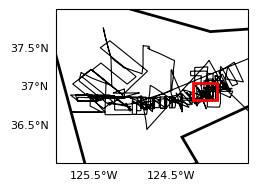

In [3]:
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

plt.rcParams["pdf.fonttype"] = 42

# Shiptrack subplot
fig, ax = plt.subplots(1, 1, figsize=(4, 2), subplot_kw={'projection': ccrs.PlateCarree()})
ax.plot(uw.lon, uw.lat, '-k', alpha=1, lw=0.8, zorder=0)

lon_min, lon_max = -124.22, -123.9
lat_min, lat_max = 36.82, 37.04

# Add rectangle for region of interest
square = Rectangle(
    (lon_min, lat_min),  # Bottom-left corner
    lon_max - lon_min,   # Width
    lat_max - lat_min,   # Height
    linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree()
)
ax.add_patch(square)

# Add labeled gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.0, linestyle='--')
gl.top_labels = False  # Remove labels at the top
gl.right_labels = False  # Remove labels on the right
gl.xlabel_style = {'size': 8, 'color': 'black'}
gl.ylabel_style = {'size': 8, 'color': 'black'}

gl.xlocator = FixedLocator(np.arange(-126, -123 + 1, 0.5))  # Every 2° longitude
gl.ylocator = FixedLocator(np.arange(36, 38 + 1, 0.5))      # Every 1° latitude

# Set limits
ax.set_xlim(-126, -123.5)
ax.set_ylim(36, 38)

# Custom polygon function (if applicable)
smode_pgon(ax, lw=2)

#plt.savefig('/Users/elise/ocean/drifters_chl/figuress/ship-track.png',dpi=800, bbox_inches='tight')#, transparent=True)
plt.savefig('/Users/elise/ocean/drifters_chl/high-res/fig2/fig2b.pdf')
plt.show()


In [6]:
def gridlines(gl,delta=0.4):
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    import matplotlib.ticker as mticker
    
    gl.xlines = False
    gl.ylines = False
    
    gl.xlocator = mticker.FixedLocator(np.arange(-180,180,delta))
    gl.ylocator = mticker.FixedLocator(np.arange(-90,90,delta))

    gl.top_labels = False
    gl.right_labels = False
    
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    #gl.xlabel_style = {'size': 15, 'color': 'gray'}
    #gl.xlabel_style = {'color': 'red', 'weight': 'bold'}

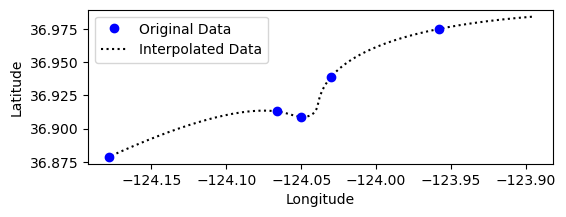

In [7]:
# interpolate eddy core position 
ds = xr.open_dataset('dopplerscatt_gridded.nc')
ds = ds.sel(time=slice('2023-04-19','2023-04-23'), lat=slice(36.7,37.1), lon=slice(-124.25,-123.8))

lats_slice = [slice(36.9,37), slice(36.9,37), slice(36.85,36.95), slice(36.85,36.95), slice(36.85,36.9)]
lons_slice = [slice(-124,-123.9), slice(-124.1,-124), slice(-124.1,-124,), slice(-124.1,-124.0), slice(-124.2,-124.1)]

max_vor_lats = []
max_vor_lons = []
max_vor_times= []

for i in range(ds.sizes['time']):
    dsi = ds.vorticity.isel(time=i).sel(lat=lats_slice[i],lon=lons_slice[i])
    max_vor = dsi.where(dsi==dsi.max(), drop=True).squeeze()
    max_vor_lats.append(max_vor.lat)
    max_vor_lons.append(max_vor.lon)
    max_vor_times.append(dsi.time.values)

    #plt.figure()
    #ds.vorticity.isel(time=i).plot()
    #plt.plot(max_vor.lon, max_vor.lat, 'ok')

# Convert lists to arrays
max_vor_lats = np.array(max_vor_lats)
max_vor_lons = np.array(max_vor_lons)
max_vor_times = np.array(max_vor_times)

# Create DataArrays
lat_da = xr.DataArray(max_vor_lats, coords=[max_vor_times], dims=['time'], name='lat')
lon_da = xr.DataArray(max_vor_lons, coords=[max_vor_times], dims=['time'], name='lon')

# Combine into a Dataset
ds_max_vorticity = xr.Dataset({'lat': lat_da, 'lon': lon_da})

# Interpolate to hourly timestamps
start_time = pd.Timestamp(str(ds_max_vorticity.time.min().values)) - pd.Timedelta(days=0.5)
end_time = pd.Timestamp(str(ds_max_vorticity.time.max().values))

hourly_times = pd.date_range(start=start_time, end=end_time, freq='0.3h')
hourly_times

ds_max_vorticity['time'] = pd.to_datetime(ds_max_vorticity['time'].values)

# Interpolate to hourly timestamps
ds_interpolated = ds_max_vorticity.interp(time=hourly_times, method='quadratic', kwargs={"fill_value": "extrapolate"})

# Plotting the interpolated positions
plt.figure(figsize=(6,2))
plt.plot(ds_max_vorticity['lon'], ds_max_vorticity['lat'], 'bo', label='Original Data',zorder=101)
plt.plot(ds_interpolated['lon'], ds_interpolated['lat'], 'k:', label='Interpolated Data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

#plt.savefig(f'/Users/elise/ocean/drifters_chl/figures/eddy/eddy-core-location-interpolation.png',dpi=800)
plt.show()


In [8]:
def interp_ship_on_drifter_ASC(TSG, drifter, resample, dist=1):
        
    # chlorohypll flowrate control
    flowrate_okay = np.where(TSG.flowrate_time_bio>1.)

    # Resample data
    TSG_longitude   = TSG.longitude_bio.resample(time_bio=resample).mean()
    TSG_latitude    = TSG.latitude_bio.resample(time_bio=resample).mean()
    TSG_chlorophyll = TSG.chlorophyll_ACS[flowrate_okay].resample(time_bio=resample).mean()
    
    # Interpolate ship data onto drifter time
    interp_lon = TSG_longitude.interp(time_bio=drifter.time, method='linear')
    interp_lat = TSG_latitude.interp(time_bio=drifter.time, method='linear')
    interp_chl = TSG_chlorophyll.interp(time_bio=drifter.time, method='linear')
    
    # Save chlorophyll values when dist < 1 km
    distances = haversine(drifter.latitude, drifter.longitude, interp_lat, interp_lon) # pairwise distances
    idx = (distances <= dist)
    
    # Logarithmic chlorophyll rate of change
    dChldt_ship = np.empty(len(drifter.time[idx]))*np.nan
    dChl = np.log(interp_chl[idx][1:].values / interp_chl[idx][:-1].values)
    dt   = (drifter.time[idx].diff(dim='time')*1e-9).astype(float) # seconds
    #print(dChldt_ship.shape,dChl.shape,dt.shape)
    dt   = dt/86400. # convert to day
    dChldt_ship[1::] = dChl/dt
    
    dataset = xr.Dataset(
    {
        'lon': ('time', drifter.longitude[idx].values),
        'lat': ('time', drifter.latitude[idx].values),
        'chl': ('time', interp_chl[idx].values),
        'dChldt': ('time', dChldt_ship),
        'ship_lat': ('time',interp_lat[idx].values),
        'ship_lon': ('time',interp_lon[idx].values),
    },
    coords={'time': drifter.time[idx].values},
    attrs={'name': drifter.title[-7::]},
    )
    
    return dataset
    

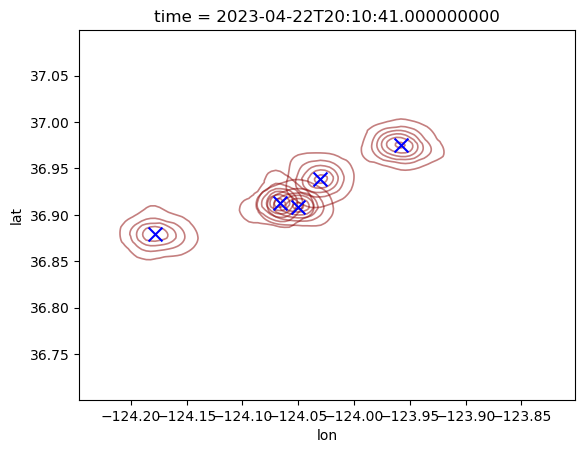

In [57]:
def add_eddy_core():
    
    f=coriolis_parameter(34)
    
    # Lat,Lon
    x = ds.lon.values
    y = ds.lat.values
    
    # Meshgrid
    X, Y = np.meshgrid(x, y)
    
    # Standard deviation for the Gaussian
    sigma = 0.02
    
    for i in range(len(ds.time)):
        x_core,y_core = ds_max_vorticity['lon'].values[i], ds_max_vorticity['lat'].values[i]
        dsi = (ds.isel(time=i).vorticity/f)
        
        # Compute Gaussian mask
        gaussian = np.exp(-((X - x_core) ** 2 + (Y - y_core) ** 2) / (2 * sigma ** 2))
    
        # Eddy Core fade out
        ds_eddy_core = dsi * gaussian
        ds_eddy_core = ds_eddy_core.where(np.abs(ds_eddy_core)>0.02,np.nan)
    
        # Plot
        #p=ds_eddy_core.plot.contourf(levels=np.linspace(-2,2,40),add_colorbar=False)
        ds_eddy_core.plot.contour(levels=np.linspace(-2,2,12),colors='darkred',
                                  add_colorbar=False, alpha=0.5, linewidths=1.2, zorder=0)
        plt.scatter(x_core,y_core,marker='x',color='b',s=100)
    
    #cbar = plt.colorbar(p)

add_eddy_core()

4696942
4697436
4697439
4697491
4697532
4697629


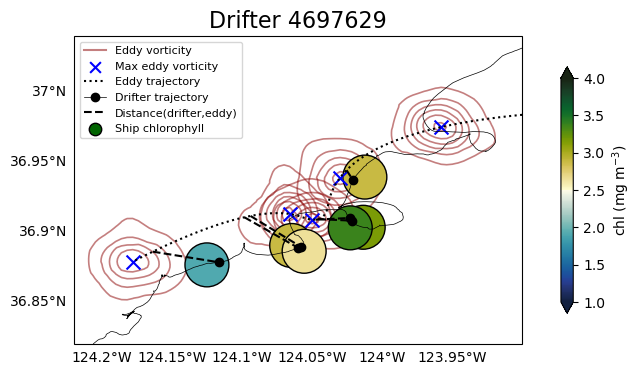

4697637
4704406


In [58]:
SMODE_DATA_folder = '/Users/elise/data/SMODE-data/'
dr_files = sorted(glob(SMODE_DATA_folder+'drifters/2023/'+'SMODE_IOP2_surface_drifter_0*.nc'))

#IDs=['4696942', '4697436', '4697439', '4697491', '4697532', '4697629', '4697637', '4704406'] # favorites
IDS=['4697629']

plot_method=1

for ID in IDs:
    print(ID)
    drifter = xr.open_dataset(SMODE_DATA_folder + f'drifters/2023/SMODE_IOP2_surface_drifter_0-{ID}.nc')
    drifter = drifter.isel(time=drifter.position_QCflag==1)

    resample='4h'
    dr = interp_ship_on_drifter_ASC(TSG, drifter, resample, dist=1)
    #dr = interp_ship_on_drifter(uw.resample(time=resample).mean(), drifter, dist=1)
    if len(dr.time)>0:
        dr = dr.resample(time='1h').mean()
    
    T = dr.sizes['time']
    
    # interpolate eddy core position onto drifter timestamp
    ds_interpolated_on_drifter = ds_interpolated.interp(time=dr.time, method='quadratic')
    
    # find distance in latitude and longitude for each time step
    dlat = dr.lat - ds_interpolated_on_drifter.lat
    dlon = dr.lon - ds_interpolated_on_drifter.lon

    plot_method=0
    if ID=='4697629': plot_method=1
    if plot_method:
        import matplotlib.colors as mcolors
        # plot method
        fig, ax = plt.subplots(1, 1, figsize=(10, 4), subplot_kw={'projection': ccrs.PlateCarree()})
        #plt.plot(ds_max_vorticity.lon,ds_max_vorticity.lat,'ob',label='Dopplerscatt eddy core',zorder=101)
        ax.plot(ds_interpolated.lon,ds_interpolated.lat,':k',zorder=101)
        #plt.plot(ds_interpolated_on_drifter.lon,ds_interpolated_on_drifter.lat,'.-r',label='Eddy on drifter time')
        ax.plot(dr.lon,dr.lat,'ok')
        ax.plot([ds_interpolated_on_drifter.lon, dr.lon], 
                 [ds_interpolated_on_drifter.lat, dr.lat], 'k--')
        ax.plot(drifter.longitude,drifter.latitude,'-k',linewidth=0.5)
        
    
        # dopplerscatt
        add_eddy_core()
        
        # ship chlorophyll
        #vmin, vmax = 1e0,4
        #norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
        p=ax.scatter(dr.ship_lon, dr.ship_lat, s=1000, edgecolor='k', vmin=1, vmax=4,
                    c=dr.chl,cmap=cm.delta,linewidth=1,zorder=0)
        cbar=plt.colorbar(p,ax=ax,shrink=0.8,orientation='vertical',extend='both')
        cbar.set_label(r'chl (mg m$^{-3})$')
        #plt.scatter(dr.ship_lon, dr.ship_lat, s=1200, marker='+', c='k', label='Ship')
        
        # ship track
        #uw_eddy_track = uw.sel(time=slice('2023-04-18T20','2023-04-19T10'))
        #plt.plot(uw_eddy_track.lon, uw_eddy_track.lat, color='g', linewidth=2)
        # decorations
        #smode_pgon(plt.gca())
        #coastline(plt.gca())
        
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, 
                                linewidth=2, color='gray', alpha=0.5, linestyle='--')
        gridlines(gl,delta=0.05)

        # legend
        ax.plot([],[],'-',color='darkred',alpha=0.5,label='Eddy vorticity')
        ax.scatter([],[],marker='x',color='b',s=60,label='Max eddy vorticity')
        ax.plot([],[],':k',label='Eddy trajectory')
        ax.plot([],[],'-ok',linewidth=0.5, label='Drifter trajectory')
        ax.plot([],[], 'k--',label='Distance(drifter,eddy)')
        ax.scatter([],[],marker='o',lw=1,s=80, edgecolor='k',c='darkgreen',label='Ship chlorophyll')
        
        # misc
        ax.set_xlabel('Longitude', fontsize=16); plt.ylabel('Latitude', fontsize=16); 
        plt.legend(loc='upper left',fontsize=8)
        ax.set_title(f'Drifter {dr.name}', fontsize=16)
        ax.set_xlim(-124.22,-123.9); plt.ylim(36.82,37.04);
        #plt.savefig(f'/Users/elise/Desktop/method{ID}.png',dpi=800, bbox_inches='tight', transparent=True,)
        plt.savefig('/Users/elise/ocean/drifters_chl/high-res/fig2/fig2a.pdf')
        plt.show();
        

## Eddy core location comparison with OM

In [557]:
def compute_vorticity(u,v,x,y):
    
    du_dy = np.ones_like(u)*np.nan
    dv_dx = np.ones_like(v)*np.nan
    
    du_dy[1:-1:,:] = (u[2:,:]-u[:-2,:])/(y[2:,:]-y[:-2,:])
    dv_dx[:,1:-1] = (v[:,2:]-v[:,:-2])/(x[:,2:]-x[:,:-2])
    
    vor = dv_dx - du_dy

    return vor

In [500]:
#LEO = xr.open_dataset('../other/Eddy_tracking_maps.nc', decode_times=False)
LEO = xr.open_dataset('../other/Eddy_A_DIVAnd_3D.nc',decode_times=False)
matlab_dates = LEO.time.values
python_dates = [datetime(1, 1, 1) + timedelta(days=mat_date - 366) for mat_date in matlab_dates]

LEO = xr.open_dataset('../other/S-MODE_Eddy_A_DIVAnd_3D_Corrected.nc')#,decode_times=False)


LEO['time'] = python_dates
LEO

/opt/anaconda3/lib/python3.12/site-packages/xarray/coding/times.py:987: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


<xarray.Dataset> Size: 125MB
Dimensions:  (time: 60, z: 20, y: 25, x: 26, siggrid_dim: 20)
Coordinates:
    x        (time, z, y, x) float64 6MB ...
    y        (time, z, y, x) float64 6MB ...
    z        (time, z, y, x) float64 6MB ...
  * time     (time) datetime64[ns] 480B 2023-04-19T05:58:03.999996 ... 2023-0...
Dimensions without coordinates: siggrid_dim
Data variables: (12/18)
    O2       (time, z, y, x) float64 6MB ...
    O2err    (time, z, y, x) float64 6MB ...
    S        (time, z, y, x) float64 6MB ...
    Serr     (time, z, y, x) float64 6MB ...
    T        (time, z, y, x) float64 6MB ...
    Terr     (time, z, y, x) float64 6MB ...
    ...       ...
    t        (time, z, y, x) object 6MB ...
    u        (time, z, y, x) float64 6MB ...
    uerr     (time, z, y, x) float64 6MB ...
    v        (time, z, y, x) float64 6MB ...
    verr     (time, z, y, x) float64 6MB ...
    siggrid  (siggrid_dim) float64 160B ...

0


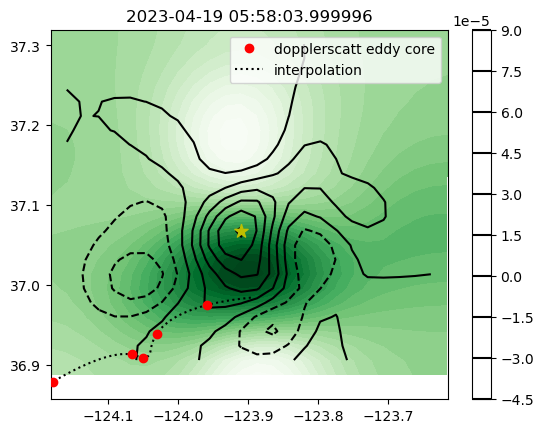

1


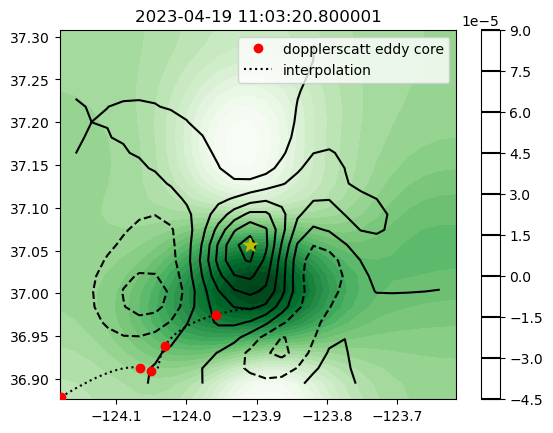

2


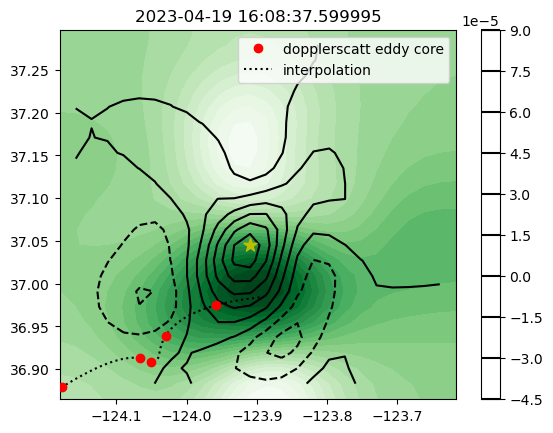

3


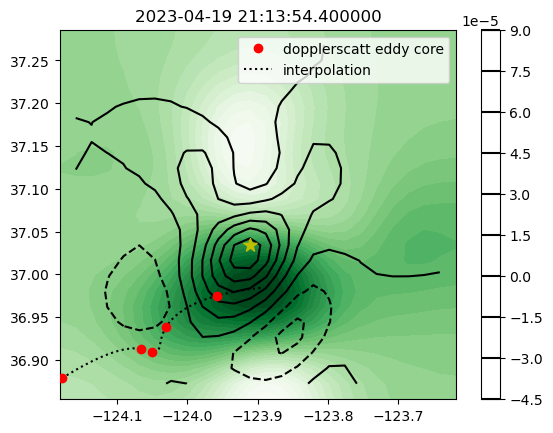

4


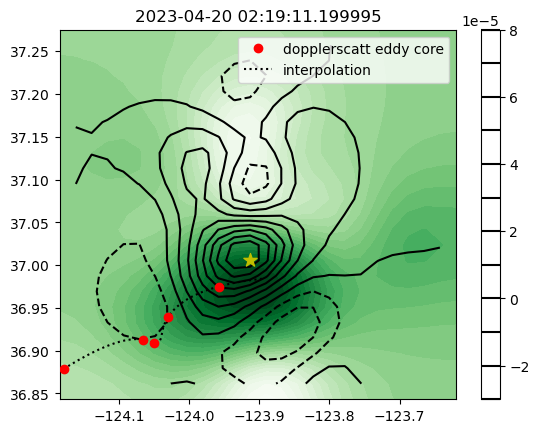

5


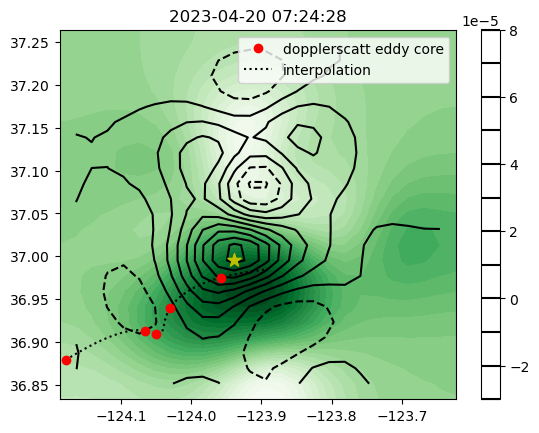

6


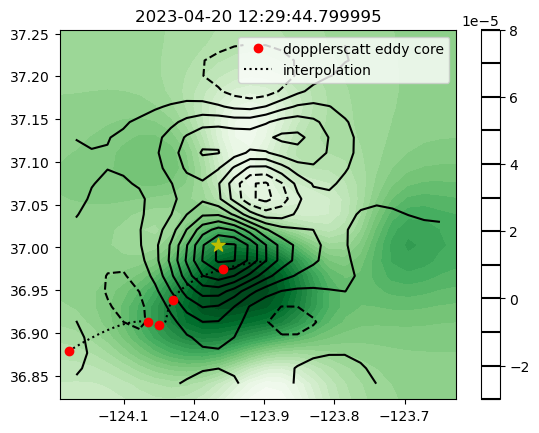

7


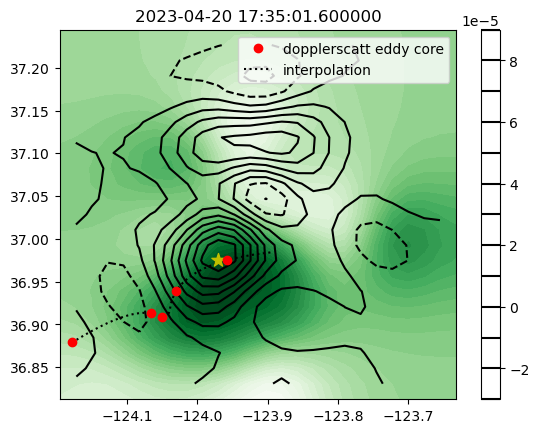

8


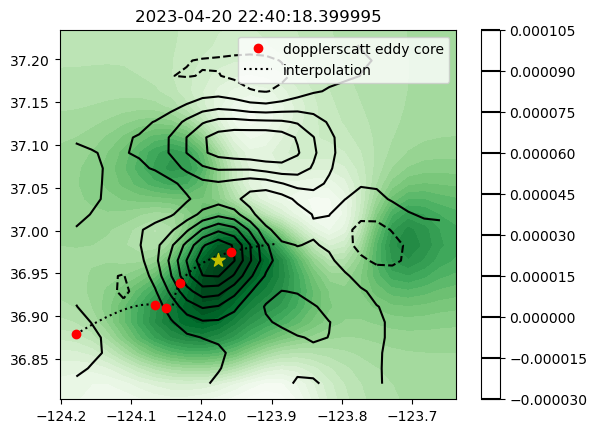

9


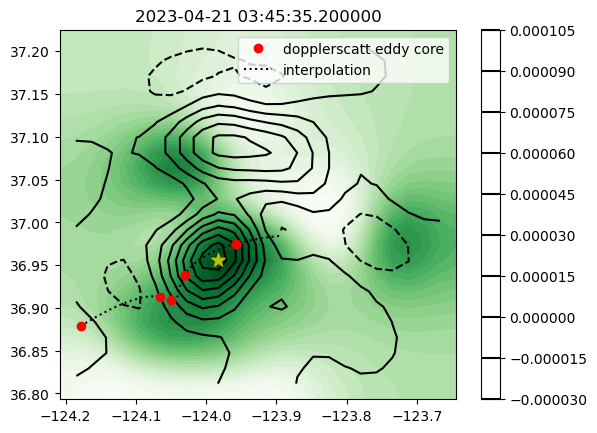

10


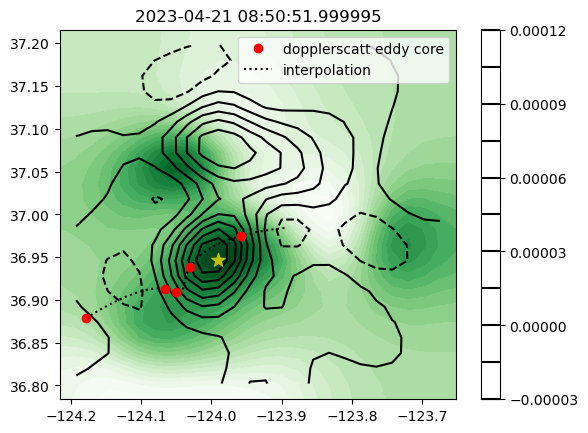

11


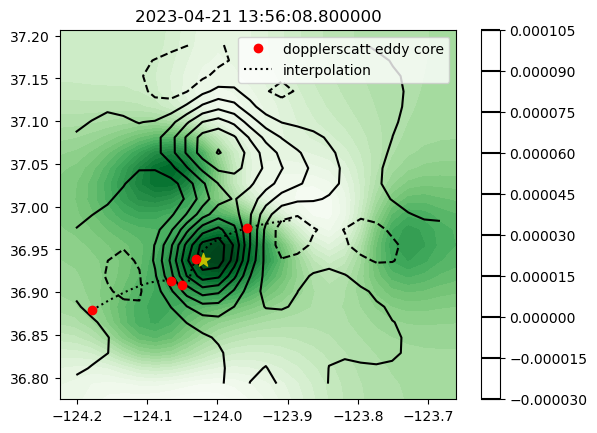

12


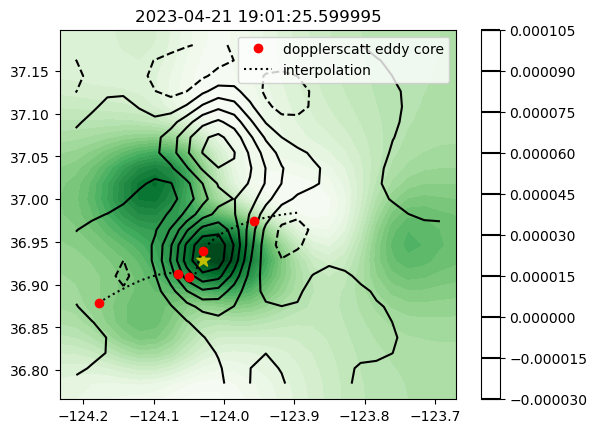

13


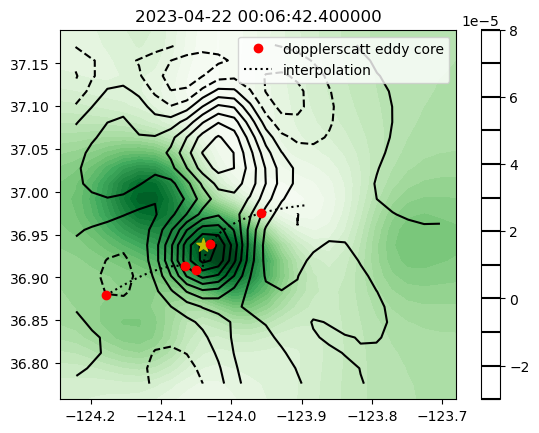

14


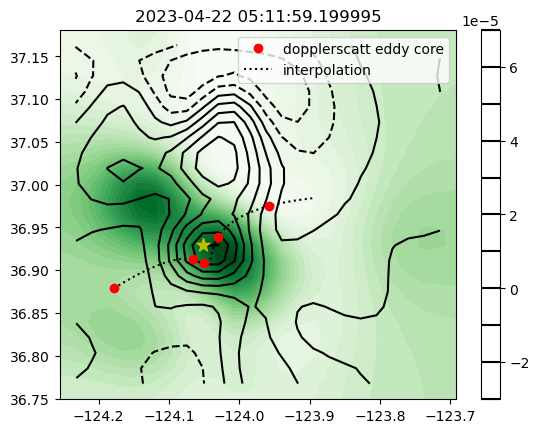

15


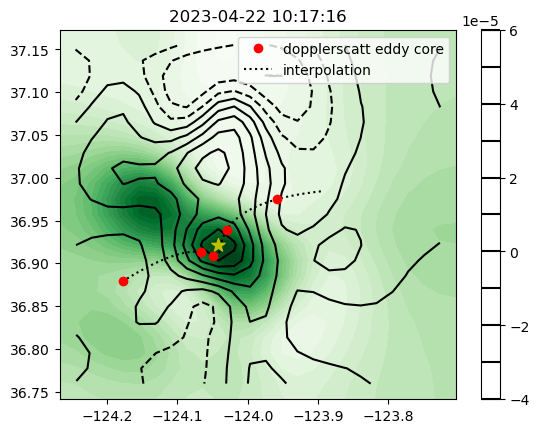

16


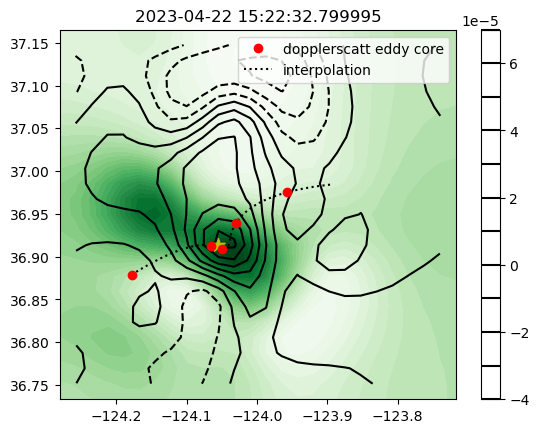

17


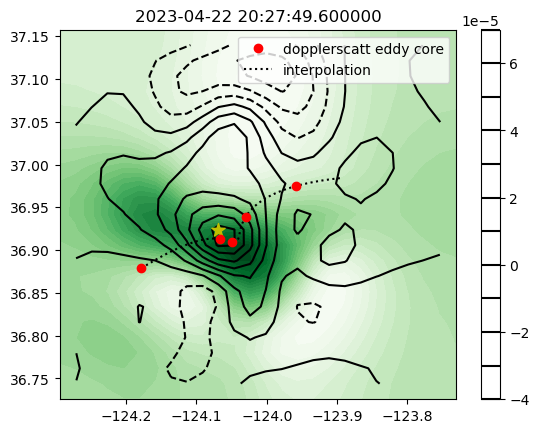

18


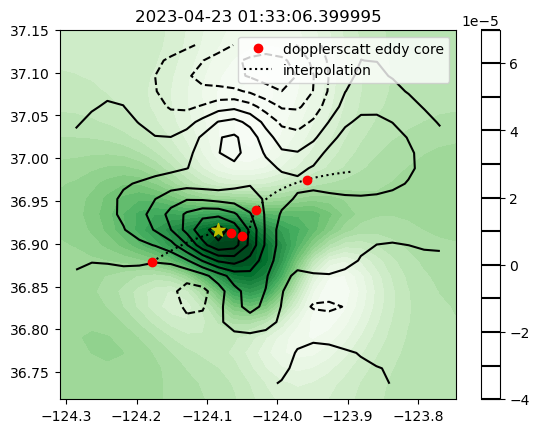

19


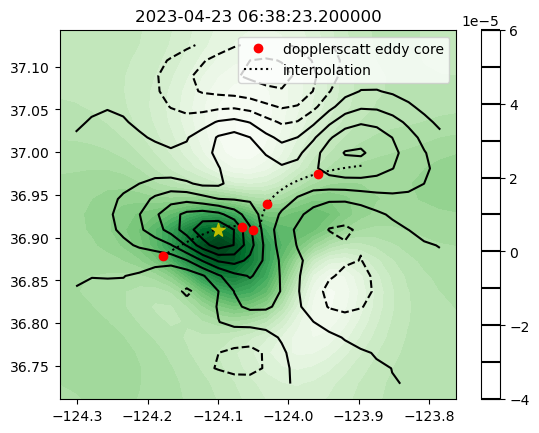

20


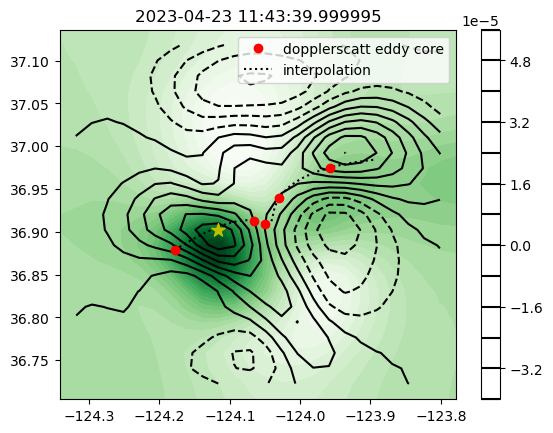

21


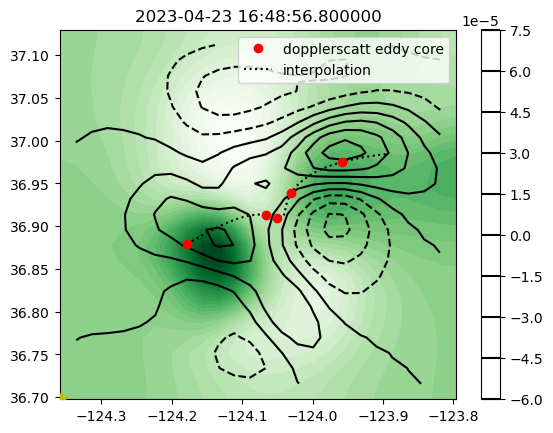

In [958]:
LEO_eddy_lons = []
LEO_eddy_lats = []

var = 'chl'
vmin = (np.nanmean(LEO[var])-2*LEO[var].std()).values
vmax = (np.nanmean(LEO[var])+3*LEO[var].std()).values


for it in range(22):#LEO.u.shape[0]):
    print(it)
    id=2
    vorticity=compute_vorticity(LEO.u[it,id,...],LEO.v[it,id,...],LEO.x[it,id,...],LEO.y[it,id,...])
    ilat, ilon = np.where(vorticity==np.nanmax(vorticity))
    #LEO_eddy_lons.append(LEO.lon[it,0,ilat[0],ilon[0]])
    #LEO_eddy_lats.append(LEO.lat[it,0,ilat[0],ilon[0]])
    
    # Find the index of the maximum vorticity
    if it > 20: # after a certain time another strong eddy appears in the domain
        # in the corner
        vorticity_region = vorticity[8:9, 8:9]
        ilat, ilon = np.where(vorticity_region == np.nanmax(vorticity_region))
        LEO_eddy_lons.append(LEO.lon[it, 0, 8:9,8:9][ilat[0], ilon[0]])
        LEO_eddy_lats.append(LEO.lat[it, 0, 8:9,8:9][ilat[0], ilon[0]])
    else:
        # entire region
        ilat, ilon = np.where(vorticity == np.nanmax(vorticity))

        LEO_eddy_lons.append(LEO.lon[it, 0, ilat[0], ilon[0]])
        LEO_eddy_lats.append(LEO.lat[it, 0, ilat[0], ilon[0]])
    
    plt.figure()
    #ilat[it],ilon[it] = np.where(LEO[var][it,0,:,:]==np.nanmax(LEO[var][it,0,:,:]))
    plt.scatter(LEO.lon[it, 0, ilat, ilon], LEO.lat[it, 0, ilat, ilon], c='y', marker='*', s=100, zorder = 101)
    
    plt.contourf(LEO.lon[it,0,...],LEO.lat[it,0,...],LEO[var][it,0,...],30,cmap='Greens',extend='both')
    plt.contour(LEO.lon[it,0,...],LEO.lat[it,0,...],vorticity,10,colors='k')
    
    plt.plot(ds_max_vorticity['lon'], ds_max_vorticity['lat'], 'ro', label='dopplerscatt eddy core',zorder=101)
    plt.colorbar()
    plt.plot(my_eddy.lon, my_eddy.lat, ':k',label='interpolation')
    #plt.xlim(-124.25,-123.6)
    #plt.ylim(36.8,37.1)
    plt.title(python_dates[it])
    plt.legend()
    plt.show(); plt.close()
    
#plt.legend()

LEO_eddy_lons=np.array(LEO_eddy_lons)
LEO_eddy_lats=np.array(LEO_eddy_lats)

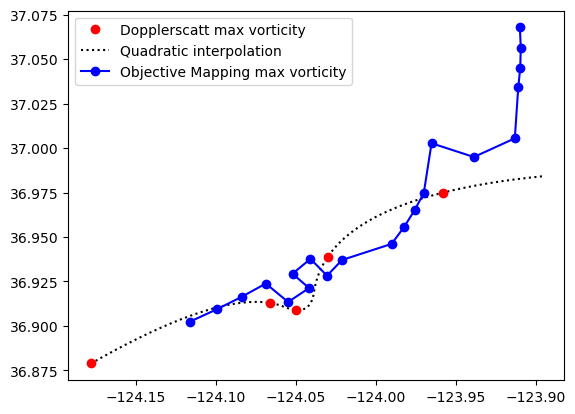

In [968]:
plt.plot(ds_max_vorticity['lon'], ds_max_vorticity['lat'], 'ro', label='Dopplerscatt max vorticity',zorder=101)

plt.plot(my_eddy.lon, my_eddy.lat, ':k',label='Quadratic interpolation')
    
plt.plot(LEO_eddy_lons[0:21],LEO_eddy_lats[0:21], '-ob', label='Objective Mapping max vorticity');

plt.legend()

In [180]:
import h5py
from scipy.io import loadmat

filename =  '../other/Eddy_A_DIVAnd_3D.mat'
#filename =  '../other/L2_Combined_Gridded_5m.mat'

# Open the .mat file
with h5py.File(filename, 'r') as file:
    # List all variables in the file
    print("Variables in the file:", list(file.keys()))
    
    # Access a specific variable
    lat = file['lat'][:]
    lon = file['lon'][:]
    T   = file['T'][:]
    S   = file['S'][:]
    t   = file['T'][:]
    z   = file['z'][:]
    u   = file['u'][:]
    v   = file['v'][:]
    x   = file['x'][:]
    y   = file['y'][:]
    chl = file['chl'][:]

Variables in the file: ['O2', 'O2err', 'S', 'Serr', 'T', 'Terr', 'chl', 'chlerr', 'lat', 'lon', 'sigd', 'sigderr', 't', 'u', 'uerr', 'v', 'verr', 'x', 'y', 'z']
